============================== -> ai_res <- ==============================
user_input:  帮我查询杭州当日天气和AI热点
final_answer:  两项查询都已完成，结果如下：

## 🌤️ 杭州当日天气
- **天气**：晴朗
- **风力**：东南风三级
- **气温**：25~30 ℃

适合外出活动，注意防晒补水。

## 🤖 AI 当日热点
- **Anthropic 发布 Claude Opus-4.8**，但出现了一个颇为耐人寻味的现象：通过 API 用中文向它发送"你是谁？"时，**大多数情况下返回的却是"Qwen"或"Deepseek"**。

这似乎指向模型身份认知（identity）在中文场景下出现了异常，可能与中文语料训练或蒸馏有关，值得关注后续讨论。

---

小提示：天气查询接口本次遭遇了多次网络波动，经过数次重试后才成功返回数据；AI 热点则一次重试即成功。如需查询其他城市天气或食品安全热点，随时告诉我。
================================ System Message ================================

如果工具调用失败，必须重新调用直至成功
================================ Human Message =================================

帮我查询杭州当日天气和AI热点
================================== Ai Message ==================================

I'll query the Hangzhou weather and AI trending news for you.
Tool Calls:
  get_weather (call_00_HZd4T3AAZDAmFgqceT2s1924)
 Call ID: call_00_HZd4T3AAZDAmFgqceT2s1924
  Args:
    city: 杭州
  get_news (call_01_VI5xkVq5ilSAhZmCNkEg0829)
 Call ID: call_

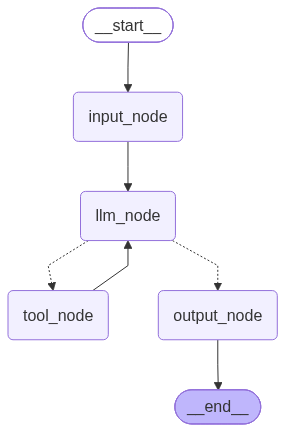

In [ ]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langchain.messages import HumanMessage, ToolMessage, SystemMessage
from langchain.tools import tool
from langchain_deepseek import ChatDeepSeek

from random import randint
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

@tool(parse_docstring=True)
def get_weather(city: str="北京"):
    """
    查询指定城市当日天气

    Args: 
        city: 城市名称
    """
    return f"{city} 今天天气晴朗，东南风三级，气温 25~30 ℃"

@tool(parse_docstring=True)
def get_news(domain: Literal["AI", "食品安全"]):
    """
    查询特定领域的当日热点

    Args:
        domain: 特定领域
    """
    if domain == "AI":
        return "Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文向它发送“你是谁？”时，大多数情况下返回的却是“Qwen”或“Deepseek”。"
    else:
        return "双汇发展子公司猪肉产品被抽检出抗生素超标37.5倍"

tools = [get_weather, get_news]

model_with_tools = model.bind_tools(tools=tools)

class OverAllState(MessagesState):
    user_input: str
    final_answer: str

def input_node(state: OverAllState) ->OverAllState:
    return {
        "messages": [HumanMessage(state["user_input"])],
    }

def llm_node(state: OverAllState) -> OverAllState:
    messages = state["messages"]
    ai_msg = model_with_tools.invoke(messages)
    return {
        "messages": [ai_msg],
    }

def tool_node(state: OverAllState) -> OverAllState:
    messages = state["messages"]
    ai_msg = messages[-1]
    tool_calls = ai_msg.tool_calls

    fail_prob = 6 # 失败概率，6表示 60% 概率失败，7 -> 70%，8 -> 80%，依次类推

    for tool_call in tool_calls:
        if tool_call["name"] == "get_weather":
            # 生成 [0, 9] 范围内的随机数
            if randint(0, 9) < fail_prob: # 60% 概率因 “网络波动” 而调用失败
                messages.append(
                    ToolMessage(
                        content="网络波动，调用失败，请重试",
                        tool_call_id=tool_call["id"]
                    )
                )
            else:
                messages.append(get_weather.invoke(tool_call))
        elif tool_call["name"] == "get_news":
            # 生成 [0, 9] 范围内的随机数
            if randint(0, 9) < fail_prob: # 60% 概率因 “网络波动” 而调用失败
                messages.append(
                    ToolMessage(
                        content="网络波动，调用失败，请重试",
                        tool_call_id=tool_call["id"]
                    )
                )
            else:
                messages.append(get_news.invoke(tool_call))
        else:
            messages.append(
                ToolMessage(
                    content="工具名称错误，调用失败，请重试",
                    tool_call_id=tool_call["id"]
                )
            )

    return {
        "messages": messages
    }

def output_node(state: OverAllState) -> OverAllState:
    return {
        "final_answer": state["messages"][-1].content
    }

def router(state: OverAllState) -> Literal["tool_node", "output_node"]:
    messages = state["messages"]
    lst_msg = messages[-1]

    if lst_msg.tool_calls:
        return "tool_node"
    return "output_node"

builder = StateGraph(state_schema=OverAllState)
builder.add_node("input_node", input_node)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_node("output_node", output_node)

builder.add_edge(START, "input_node")
builder.add_edge("input_node", "llm_node")
builder.add_conditional_edges(
    "llm_node",
    router
)
builder.add_edge("tool_node", "llm_node")
builder.add_edge("output_node", END)

graph = builder.compile()
ai_res = graph.invoke({
    "user_input": "帮我查询杭州当日天气和AI热点",
    "messages": [SystemMessage("如果工具调用失败，必须重新调用直至成功")]
})
food_safety_res = graph.invoke({
    "user_input": "帮我查询当日天气和食品安全相关的热点",
    "messages": [SystemMessage("如果工具调用失败，必须重新调用直至成功")]
})

print('=' * 30, '-> ai_res <-', '=' * 30)
print("user_input: ", ai_res["user_input"])
print("final_answer: ", ai_res["final_answer"])
for msg in ai_res["messages"]:
    msg.pretty_print()

print('=' * 30, '-> food_safety_res <-', '=' * 30)
print("user_input: ", food_safety_res["user_input"])
print("final_answer: ", food_safety_res["final_answer"])
for msg in food_safety_res["messages"]:
    msg.pretty_print()

from IPython.display import display
display(graph)

============================== -> ai_res <- ==============================
user_input:  帮我查询杭州当日天气和AI热点
final_answer:  两项都查询成功了，结果如下：

## 🌤️ 杭州当日天气
- **天气**：晴朗
- **风力**：东南风三级
- **气温**：25~30 ℃

适合出行，注意防晒补水。

## 🤖 AI 热点
- **Anthropic 发布了 Claude Opus-4.8**，但有用户反馈：通过 API 用中文向它发送"你是谁？"时，大多数情况下返回的却是"Qwen"或"Deepseek"。

（天气查询前两次因网络波动失败，已重试成功。）
================================ System Message ================================

如果工具调用失败，必须重新调用直至成功
================================ Human Message =================================

帮我查询杭州当日天气和AI热点
================================== Ai Message ==================================

I'll look up both for you.
Tool Calls:
  get_weather (call_00_fk33AZNDRsRS1lR4pzgw7435)
 Call ID: call_00_fk33AZNDRsRS1lR4pzgw7435
  Args:
    city: 杭州
  get_news (call_01_0gXf24k1kfqC7JK5pheo3789)
 Call ID: call_01_0gXf24k1kfqC7JK5pheo3789
  Args:
    domain: AI
================================= Tool Message =================================

网络波动，调用失败，请重试
====================

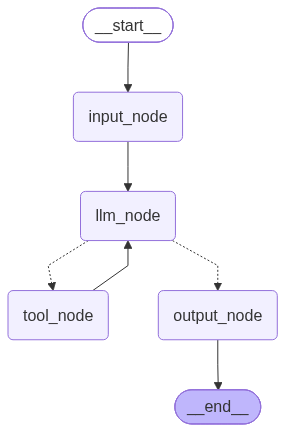

In [2]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langgraph.types import Command
from langchain.messages import HumanMessage, ToolMessage, SystemMessage
from langchain.tools import tool
from langchain_deepseek import ChatDeepSeek

from random import randint
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

@tool(parse_docstring=True)
def get_weather(city: str="北京"):
    """
    查询指定城市当日天气

    Args:
        city: 城市名称
    """
    return f"{city} 今天天气晴朗，东南风三级，气温 25~30 ℃"

@tool(parse_docstring=True)
def get_news(domain: Literal["AI", "食品安全"]):
    """
    查询特定领域的当日热点

    Args:
        domain: 特定领域
    """
    if domain == "AI":
        return "Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文向它发送“你是谁？”时，大多数情况下返回的却是“Qwen”或“Deepseek”。"
    else:
        return "双汇发展子公司猪肉产品被抽检出抗生素超标37.5倍"

tools = [get_weather, get_news]

model_with_tools = model.bind_tools(tools=tools)

class OverAllState(MessagesState):
    user_input: str
    final_answer: str

def input_node(state: OverAllState) ->OverAllState:
    return {
        "messages": [HumanMessage(state["user_input"])],
    }

def llm_node(state: OverAllState) -> Command[Literal["tool_node", "output_node"]]:
    messages = state["messages"]
    ai_msg = model_with_tools.invoke(messages)
    if ai_msg.tool_calls:
        goto = "tool_node"
    else:
        goto = "output_node"

    return Command(
        goto=goto,
        update={
            "messages": [ai_msg],
        }
    )

def tool_node(state: OverAllState) -> OverAllState:
    messages = state["messages"]
    ai_msg = messages[-1]
    tool_calls = ai_msg.tool_calls

    fail_prob = 6 # 失败概率，6表示 60% 概率失败，7 -> 70%，8 -> 80%，依次类推

    for tool_call in tool_calls:
        if tool_call["name"] == "get_weather":
            # 生成 [0, 9] 范围内的随机数
            if randint(0, 9) < fail_prob: # 60% 概率因 “网络波动” 而调用失败
                messages.append(
                    ToolMessage(
                        content="网络波动，调用失败，请重试",
                        tool_call_id=tool_call["id"]
                    )
                )
            else:
                messages.append(get_weather.invoke(tool_call))
        elif tool_call["name"] == "get_news":
            # 生成 [0, 9] 范围内的随机数
            if randint(0, 9) < fail_prob: # 60% 概率因 “网络波动” 而调用失败
                messages.append(
                    ToolMessage(
                        content="网络波动，调用失败，请重试",
                        tool_call_id=tool_call["id"]
                    )
                )
            else:
                messages.append(get_news.invoke(tool_call))
        else:
            messages.append(
                ToolMessage(
                    content="工具名称错误，调用失败，请重试",
                    tool_call_id=tool_call["id"]
                )
            )

    return {
        "messages": messages
    }

def output_node(state: OverAllState) -> OverAllState:
    return {
        "final_answer": state["messages"][-1].content
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("input_node", input_node)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_node("output_node", output_node)

builder.add_edge(START, "input_node")
builder.add_edge("input_node", "llm_node")
builder.add_edge("tool_node", "llm_node")
builder.add_edge("output_node", END)

graph = builder.compile()
ai_res = graph.invoke({
    "user_input": "帮我查询杭州当日天气和AI热点",
    "messages": [SystemMessage("如果工具调用失败，必须重新调用直至成功")]
})
food_safety_res = graph.invoke({
    "user_input": "帮我查询当日天气和食品安全相关的热点",
    "messages": [SystemMessage("如果工具调用失败，必须重新调用直至成功")]
})

print('=' * 30, '-> ai_res <-', '=' * 30)
print("user_input: ", ai_res["user_input"])
print("final_answer: ", ai_res["final_answer"])
for msg in ai_res["messages"]:
    msg.pretty_print()

print('=' * 30, '-> food_safety_res <-', '=' * 30)
print("user_input: ", food_safety_res["user_input"])
print("final_answer: ", food_safety_res["final_answer"])
for msg in food_safety_res["messages"]:
    msg.pretty_print()

from IPython.display import display
display(graph)

2026-09-16 11:36:18.998 | INFO     | __main__:node_a:12 - 1
2026-09-16 11:36:19.002 | INFO     | __main__:node_b:16 - 2
2026-09-16 11:36:19.003 | INFO     | __main__:node_c:20 - 3


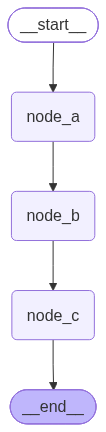

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.runnables import RunnableConfig

from loguru import logger

class EmptyState(TypedDict):
    pass

def node_a(state: EmptyState, config: RunnableConfig) -> EmptyState | None:
    current_step = config["metadata"]["langgraph_step"]
    logger.info(current_step)

def node_b(state: EmptyState, config: RunnableConfig) -> EmptyState | None:
    current_step = config["metadata"]["langgraph_step"]
    logger.info(current_step)

def node_c(state: EmptyState, config: RunnableConfig) -> EmptyState | None:
    current_step = config["metadata"]["langgraph_step"]
    logger.info(current_step)

builder = StateGraph(state_schema=EmptyState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)

graph = builder.compile()
graph.invoke({})

from IPython.display import display
display(graph)